# 02 — Data Cleaning & Preparation

**Projet** : Transmission de la politique monétaire de la BCE  
**Auteur** : ISLEYEN Volkan 
**Date** : Mai 2026

## Objectif

Transformer les données brutes collectées dans le notebook 01 en un DataFrame 
unique, propre et aligné, prêt pour l'analyse économétrique.

## Étapes

1. Chargement des données brutes depuis `data/raw/`
2. Alignement de toutes les séries sur le calendrier des jours ouvrés
3. Calcul des rendements logarithmiques de l'EURO STOXX 50
4. Calcul des variations du taux Refi BCE
5. Construction du DataFrame final et export vers `data/processed/`

## 1. Chargement des données brutes

Lecture des six séries collectées dans le notebook 01 depuis `data/raw/`.

Le fichier `sx5e.csv` nécessite un traitement particulier : l'export de yfinance 
génère deux lignes d'en-tête parasites (ticker et nom d'axe) qui sont ignorées 
au chargement via `skiprows`.

In [34]:
# Librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

# Détection automatique de la racine du projet
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = PROJECT_ROOT / "data" / "raw"

# Créer le dossier processed s'il n'existe pas 
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

print("Librairies importées")
print(f"Racine du projet : {PROJECT_ROOT}")
print(f"Données brutes : {DATA_RAW}")
print(f"Données traitées : {DATA_PROCESSED}")

Librairies importées
Racine du projet : C:\Users\volka\Documents\ecb-monetary-policy-transmission
Données brutes : C:\Users\volka\Documents\ecb-monetary-policy-transmission\data\raw
Données traitées : C:\Users\volka\Documents\ecb-monetary-policy-transmission\data\processed


In [35]:
# Chargement de toutes les données brutes sauvegardées dans le notebook 01
print("Chargement des données brutes...\n")

# EURO STOXX 50 : on saute les lignes 1 et 2 (parasites yfinance)
sx5e = pd.read_csv(DATA_RAW / "sx5e.csv", skiprows=[1, 2], index_col=0, parse_dates=True)

# Les autres fichiers se chargent normalement
vstoxx = pd.read_csv(DATA_RAW / "vstoxx_clean.csv", index_col=0, parse_dates=True)
aaa10y = pd.read_csv(DATA_RAW / "aaa_10y.csv", index_col=0, parse_dates=True)
taux_souverains = pd.read_csv(DATA_RAW / "taux_souverains.csv", index_col=0, parse_dates=True)
refi = pd.read_csv(DATA_RAW / "refi.csv", index_col=0, parse_dates=True)
bce_events = pd.read_csv(DATA_RAW / "bce_events.csv", index_col=0, parse_dates=True)

# Vérification : on affiche la forme de chaque DataFrame
datasets = {
    "EURO STOXX 50":      sx5e,
    "VSTOXX":             vstoxx,
    "AAA 10Y":            aaa10y,
    "Taux souverains":    taux_souverains,
    "Refi BCE":           refi,
    "Décisions BCE":      bce_events,
}

print(f"{'Série':<20} {'Lignes':>8} {'Colonnes':>10}   Période")
print("-" * 70)
for nom, df in datasets.items():
    debut = df.index.min().date()
    fin = df.index.max().date()
    print(f"{nom:<20} {len(df):>8} {df.shape[1]:>10}   {debut} → {fin}")

Chargement des données brutes...

Série                  Lignes   Colonnes   Période
----------------------------------------------------------------------
EURO STOXX 50            1510          1   2019-01-03 → 2024-12-30
VSTOXX                   1536          1   2019-01-02 → 2024-12-30
AAA 10Y                  1532          1   2019-01-02 → 2024-12-30
Taux souverains          1532          7   2019-01-02 → 2024-12-30
Refi BCE                 2192          1   2019-01-01 → 2024-12-31
Décisions BCE              18          2   2019-09-12 → 2024-12-12


## 2. Alignement des séries

Chaque source possède son propre calendrier : les bourses, la BCE et les marchés 
obligataires n'observent pas exactement les mêmes jours fériés. Le taux Refi est 
même publié en jours calendaires (week-ends inclus).

Toutes les séries sont alignées sur le calendrier de l'EURO STOXX 50, qui constitue 
la variable d'intérêt principale de l'étude. La série `aaa10y` n'est pas jointe 
séparément car elle est déjà incluse dans le fichier des taux souverains.

In [36]:
# Alignement de toutes les séries sur le calendrier de l'EURO STOXX 50
print("Alignement des séries sur le calendrier de l'EURO STOXX 50...\n")

# On part du STOXX 50 comme base
df = sx5e.copy()

# On ajoute chaque série une par une via un join (alignement automatique sur l'index)
df = df.join(vstoxx, how="left")
# Note : on ne joint PAS aaa10y séparément car taux_souverains contient déjà AAA_10Y
df = df.join(taux_souverains, how="left")
df = df.join(refi, how="left")

# Aperçu
print(f"DataFrame consolidé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"Période : {df.index.min().date()} → {df.index.max().date()}")
print(f"\nColonnes : {df.columns.tolist()}")
print(f"\nPremières lignes :")
print(df.head())
print(f"\nValeurs manquantes par colonne :")
print(df.isna().sum())

Alignement des séries sur le calendrier de l'EURO STOXX 50...

DataFrame consolidé : 1510 lignes, 10 colonnes
Période : 2019-01-03 → 2024-12-30

Colonnes : ['SX5E', 'VSTOXX', 'FR_10Y', 'IT_10Y', 'ES_10Y', 'AAA_10Y', 'spread_FR', 'spread_IT', 'spread_ES', 'Refi']

Premières lignes :
                   SX5E  VSTOXX  FR_10Y  IT_10Y  ES_10Y   AAA_10Y  spread_FR  \
Price                                                                          
2019-01-03  2954.659912   23.00   0.656   2.888   1.438  0.246228  40.977242   
2019-01-04  3041.850098   20.48   0.695   2.892   1.478  0.274661  42.033882   
2019-01-07  3033.639893   20.15   0.721   2.904   1.507  0.288875  43.212517   
2019-01-08  3054.939941   19.48   0.737   2.965   1.527  0.310582  42.641821   
2019-01-09  3070.239990   19.00   0.713   2.899   1.497  0.301113  41.188652   

             spread_IT   spread_ES  Refi  
Price                                     
2019-01-03  264.177242  119.177242   0.0  
2019-01-04  261.733882  120

## 3. Traitement des valeurs manquantes

Une seule observation présente des valeurs manquantes : le 14 décembre 2021, 
jour où les marchés actions cotaient mais pas les marchés obligataires.

Cette observation est complétée par forward fill (report de la dernière valeur 
connue), sous l'hypothèse que si le marché obligataire est fermé, le taux n'a 
pas évolué. L'impact est négligeable (une ligne sur 1508).

In [37]:
# Nettoyage : renommer l'index et traiter la valeur manquante

# 1. Renommer l'index "Price" → "Date"
df.index.name = "Date"

# 2. Identifier la ligne avec des valeurs manquantes
ligne_manquante = df[df.isna().any(axis=1)]
print("Ligne(s) avec valeur(s) manquante(s) :")
print(ligne_manquante)
print()

# 3. Traitement : on remplit avec la valeur de la veille (forward fill)
# Logique : si les marchés obligataires sont fermés ce jour-là,
# le taux le plus pertinent est celui du dernier jour coté
df = df.ffill()

# 4. Vérification
print(f"Valeurs manquantes après traitement : {df.isna().sum().sum()}")
print(f"\nNom de l'index : {df.index.name}")
print(f"Dimensions finales : {df.shape}")

Ligne(s) avec valeur(s) manquante(s) :
                   SX5E  VSTOXX  FR_10Y  IT_10Y  ES_10Y  AAA_10Y  spread_FR  \
Date                                                                          
2021-12-14  4144.509766   24.42     NaN     NaN     NaN      NaN        NaN   

            spread_IT  spread_ES  Refi  
Date                                    
2021-12-14        NaN        NaN   0.0  

Valeurs manquantes après traitement : 0

Nom de l'index : Date
Dimensions finales : (1510, 10)


## 4. Construction des variables d'analyse

Transformation des niveaux bruts en variables exploitables pour l'analyse 
économétrique :

- **`ret_sx5e`** : rendement logarithmique de l'EURO STOXX 50, mesure standard 
  de performance en finance (additive dans le temps)
- **`delta_vstoxx`** : variation quotidienne du VSTOXX en points
- **`delta_refi`** : variation du taux Refi — variable explicative centrale, 
  non nulle uniquement les jours de décision BCE
- **`delta_spread`** : variations quotidiennes des spreads souverains en points de base

In [38]:
# Calcul des variables d'analyse
print("Calcul des rendements et variations...\n")

# Etape 1 : Rendement logarithmique de l'EURO STOXX 50
# log(P_t / P_t-1) --> la mesure standart de performance en finance
df["ret_sx5e"] = np.log(df["SX5E"] / df["SX5E"].shift(1))

# Etape 2 : Variation quotidienne du VSTOXX (en points)

df["delta_vstoxx"] = df["VSTOXX"].diff()

# Etape 3 : Variation du taux Refi (en points de %)
# Note : delta_refi = 0 la plupart du temps, et non-nulle uniquement les jours de décision BCE
df["delta_refi"] = df["Refi"].diff()

# 4. Variations quotidiennes des spreads souverains (en points de base)
df["delta_spread_FR"] = df["spread_FR"].diff()
df["delta_spread_IT"] = df["spread_IT"].diff()
df["delta_spread_ES"] = df["spread_ES"].diff()

# La première ligne aura des NaN (pas de jour précédent pour calculer la variation)
# On la supprime
df = df.dropna()

# Aperçu
print(f"Dimensions après calculs : {df.shape}")
print(f"Période : {df.index.min().date()} → {df.index.max().date()}")
print(f"\nColonnes : {df.columns.tolist()}")
print(f"\nStatistiques des variables d'analyse :")
print(df[["ret_sx5e", "delta_vstoxx", "delta_refi", "delta_spread_IT"]].describe().round(4))


Calcul des rendements et variations...

Dimensions après calculs : (1509, 16)
Période : 2019-01-04 → 2024-12-30

Colonnes : ['SX5E', 'VSTOXX', 'FR_10Y', 'IT_10Y', 'ES_10Y', 'AAA_10Y', 'spread_FR', 'spread_IT', 'spread_ES', 'Refi', 'ret_sx5e', 'delta_vstoxx', 'delta_refi', 'delta_spread_FR', 'delta_spread_IT', 'delta_spread_ES']

Statistiques des variables d'analyse :
        ret_sx5e  delta_vstoxx  delta_refi  delta_spread_IT
count  1509.0000     1509.0000   1509.0000        1509.0000
mean      0.0003       -0.0040      0.0021          -0.1032
std       0.0126        1.8971      0.0440           6.2830
min      -0.1324      -11.9000     -0.6000         -74.7137
25%      -0.0048       -0.8300      0.0000          -3.1157
50%       0.0009       -0.1300      0.0000          -0.1252
75%       0.0064        0.5900      0.0000           2.6274
max       0.0883       17.7600      0.7500          68.8865


### Interprétation des variables d'analyse

Les statistiques descriptives confirment la cohérence des variables construites.

**Rendement de l'EURO STOXX 50 (`ret_sx5e`)**  
Moyenne quotidienne quasi nulle (0.03 %) et écart-type de 1.26 %, valeurs typiques 
d'un indice actions. Le minimum à **−13.24 %** correspond au krach lié au Covid-19 
(12 mars 2020), le maximum à **+8.83 %** au rebond violent qui a suivi quelques jours après.

**Variation du VSTOXX (`delta_vstoxx`)**  
Variations centrées sur zéro mais à queues épaisses : le maximum (+17.76 points) 
et le minimum (−11.90 points) traduisent les pics de volatilité de mars 2020. 
La volatilité évolue par à-coups brutaux plutôt que de façon continue.

**Variation du taux Refi (`delta_refi`)**  
Variable explicative centrale de l'étude. Nulle la quasi-totalité du temps 
(médiane et quartiles à 0), elle ne s'active que les jours de décision BCE. 
Les bornes observées (−0.60 à +0.75) correspondent aux amplitudes réelles 
des décisions sur la période : hausses allant jusqu'à +75 bp en 2022, 
baisses de −25 bp en 2024.

**Variation du spread italien (`delta_spread_IT`)**  
C'est le spread le plus volatil des trois (écart-type de 6.28 bp contre 
des valeurs plus faibles pour la France et l'Espagne). Les variations extrêmes 
(−74.7 et +68.9 bp) reflètent les épisodes de tension sur la dette souveraine 
italienne, indicateur classique du stress financier en zone euro.

**Synthèse**  
Toutes les variables présentent des ordres de grandeur conformes à la théorie 
financière et à l'historique de la période. Les valeurs extrêmes sont concentrées 
sur des épisodes identifiables (Covid-19, resserrement monétaire 2022), 
ce qui valide la qualité des données pour l'analyse événementielle à venir.

## 5. Vérification de la cohérence du taux Refi

Contrôle que les variations du taux Refi correspondent bien aux décisions BCE.

Deux observations méthodologiques importantes ressortent de cette vérification :

**Décalage annonce / entrée en vigueur**  
Le taux Refi change dans les données environ 6 jours après l'annonce de la BCE. 
C'est normal : la BCE *annonce* une décision, mais le nouveau taux ne prend effet 
qu'à l'opération de refinancement suivante. **L'event study se calera donc sur les 
dates d'annonce** (fichier `bce_events`), car c'est à l'annonce que les marchés réagissent.

**Ajustement technique de septembre 2024**  
Le 18 septembre 2024, le taux Refi baisse de 60 bp alors que les autres décisions 
de 2024 sont des baisses de 25 bp. La BCE a procédé ce jour-là à un resserrement 
de son corridor de taux : le taux de dépôt (qui pilote réellement les marchés 
monétaires depuis 2008) n'a baissé que de 25 bp. Cette particularité est conservée 
en l'état et signalée comme limite connue de l'étude.

In [39]:
# Vérification : les variations du taux Refi correspondent-elles aux décisions BCE ?
print("Jours où le taux Refi a changé :\n")

jours_changement = df[df["delta_refi"] != 0]
print(jours_changement[["Refi", "delta_refi"]])

print(f"\nNombre de jours avec changement de taux : {len(jours_changement)}")
print(f"Nombre de décisions BCE compilées : {len(bce_events)}")

Jours où le taux Refi a changé :

            Refi  delta_refi
Date                        
2022-07-27  0.50        0.50
2022-09-14  1.25        0.75
2022-11-02  2.00        0.75
2022-12-21  2.50        0.50
2023-02-08  3.00        0.50
2023-03-22  3.50        0.50
2023-05-10  3.75        0.25
2023-06-21  4.00        0.25
2023-08-02  4.25        0.25
2023-09-20  4.50        0.25
2024-06-12  4.25       -0.25
2024-09-18  3.65       -0.60
2024-10-23  3.40       -0.25
2024-12-18  3.15       -0.25

Nombre de jours avec changement de taux : 14
Nombre de décisions BCE compilées : 18


## 6. Sauvegarde des données nettoyées

Le DataFrame consolidé est exporté vers `data/processed/data_clean.csv`.

La séparation `raw` / `processed` garantit la reproductibilité : les données brutes 
ne sont jamais modifiées et restent la source de vérité, tandis que `processed` 
contient les données prêtes à l'analyse. Les dates de décisions BCE sont également 
copiées dans `processed/` pour que le notebook 03 dispose de toutes ses entrées 
au même endroit.

In [40]:
# Sauvegarde du DataFrame nettoyé pour les notebooks suivants
print("Sauvegarde du DataFrame nettoyé...\n")

# Chemin de sortie
chemin_sortie = DATA_PROCESSED / "data_clean.csv"

# Sauvegarde
df.to_csv(chemin_sortie, encoding="utf-8")

# Vérification
print(f"✓ Fichier sauvegardé : {chemin_sortie}")
print(f"   Dimensions : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"   Période : {df.index.min().date()} → {df.index.max().date()}")
print(f"\nColonnes sauvegardées :")
for col in df.columns:
    print(f"   - {col}")

# On sauvegarde aussi les dates de décisions BCE dans processed (pour cohérence)
bce_events.to_csv(DATA_PROCESSED / "bce_events.csv", encoding="utf-8")
print(f"\n ✓ Dates de décisions BCE également copiées dans processed/")

Sauvegarde du DataFrame nettoyé...

✓ Fichier sauvegardé : C:\Users\volka\Documents\ecb-monetary-policy-transmission\data\processed\data_clean.csv
   Dimensions : 1509 lignes, 16 colonnes
   Période : 2019-01-04 → 2024-12-30

Colonnes sauvegardées :
   - SX5E
   - VSTOXX
   - FR_10Y
   - IT_10Y
   - ES_10Y
   - AAA_10Y
   - spread_FR
   - spread_IT
   - spread_ES
   - Refi
   - ret_sx5e
   - delta_vstoxx
   - delta_refi
   - delta_spread_FR
   - delta_spread_IT
   - delta_spread_ES

 ✓ Dates de décisions BCE également copiées dans processed/


## 7. Vérification visuelle globale

Vue d'ensemble des quatre séries clés (EURO STOXX 50, VSTOXX, taux Refi, spread 
italien) avec les dates de décisions BCE matérialisées par des lignes verticales 
(rouge pour les hausses, bleu pour les baisses).

Ce graphique permet une première lecture intuitive des réactions de marché que 
l'event study quantifiera rigoureusement dans le notebook suivant.

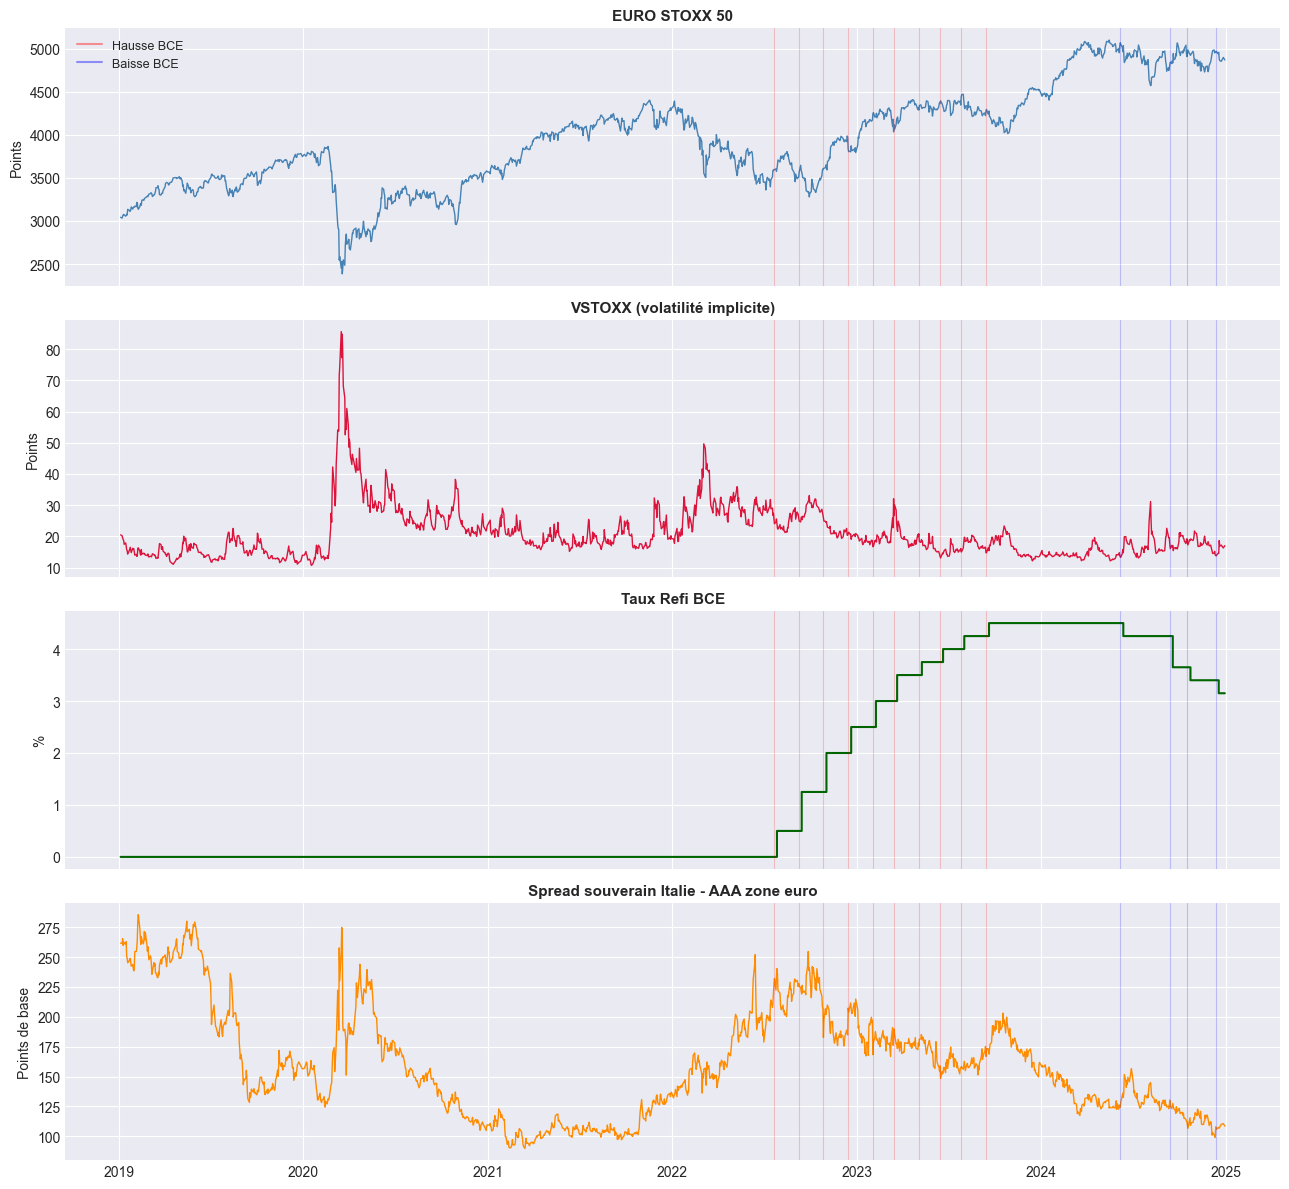

Graphique sauvegardé dans output/figures/00_data_overview.png


In [41]:
# Graphique de vérification : vue d'ensemble des données
fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)

# Dates de décisions BCE pour les lignes verticales
dates_hausse = bce_events[bce_events["Change_bp"] > 0].index
dates_baisse = bce_events[bce_events["Change_bp"] < 0].index

# --- 1. EURO STOXX 50 ---
axes[0].plot(df.index, df["SX5E"], color="steelblue", linewidth=1)
axes[0].set_title("EURO STOXX 50", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Points")

# --- 2. VSTOXX ---
axes[1].plot(df.index, df["VSTOXX"], color="crimson", linewidth=1)
axes[1].set_title("VSTOXX (volatilité implicite)", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Points")

# --- 3. Taux Refi BCE ---
axes[2].plot(df.index, df["Refi"], color="darkgreen", linewidth=1.5, drawstyle="steps-post")
axes[2].set_title("Taux Refi BCE", fontsize=11, fontweight="bold")
axes[2].set_ylabel("%")

# --- 4. Spread italien ---
axes[3].plot(df.index, df["spread_IT"], color="darkorange", linewidth=1)
axes[3].set_title("Spread souverain Italie - AAA zone euro", fontsize=11, fontweight="bold")
axes[3].set_ylabel("Points de base")

# Ajouter les lignes verticales des décisions BCE sur tous les graphiques
for ax in axes:
    for d in dates_hausse:
        ax.axvline(d, color="red", alpha=0.2, linewidth=0.8)
    for d in dates_baisse:
        ax.axvline(d, color="blue", alpha=0.2, linewidth=0.8)

# Légende manuelle
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color="red", alpha=0.4, label="Hausse BCE"),
    Line2D([0], [0], color="blue", alpha=0.4, label="Baisse BCE"),
]
axes[0].legend(handles=legend_elements, loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "output" / "figures" / "00_data_overview.png", dpi=150, bbox_inches="tight")
plt.show()

print("Graphique sauvegardé dans output/figures/00_data_overview.png")

### Lecture du graphique

Plusieurs observations ressortent de cette vue d'ensemble :

**EURO STOXX 50** — L'indice subit deux chocs majeurs sur la période : le krach 
Covid de mars 2020 (chute brutale puis rebond rapide) et la correction de 2022 
(plus progressive, concomitante au début du cycle de resserrement BCE et à la 
guerre en Ukraine). À partir de 2023, l'indice progresse malgré des taux élevés.

**VSTOXX** — La volatilité implicite est fortement asymétrique : un pic isolé 
et extrême en mars 2020, puis des niveaux globalement plus modérés. Les hausses 
de taux de 2022 s'accompagnent d'une volatilité élevée mais sans pic comparable 
à celui du Covid.

**Taux Refi** — La trajectoire en escalier illustre clairement les trois régimes 
de politique monétaire : stabilité à 0 % jusqu'à mi-2022, resserrement rapide 
(juillet 2022 – septembre 2023), puis amorce de l'assouplissement en 2024.

**Spread italien** — C'est la série qui réagit le plus visiblement aux décisions 
BCE. On observe un écartement du spread autour du début du cycle de hausses (2022), 
cohérent avec l'idée qu'un resserrement monétaire pèse davantage sur les souverains 
les plus endettés. Cette réaction fera l'objet d'une quantification précise dans 
l'event study.

**Limite de la lecture visuelle** — Ce graphique suggère des co-mouvements, mais 
ne permet pas de distinguer l'effet propre des décisions BCE du bruit de marché 
ambiant. C'est précisément le rôle de l'event study (notebook 03) : isoler la 
réaction attribuable aux annonces en neutralisant la tendance de fond.